In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [50]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update(
    {
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 9,
    }
)
RANDOM_STATE = 42
CSV_PATH = "../data/diabetes.csv"
TARGET_COL = "diabetes"

In [51]:
df = pd.read_csv(CSV_PATH)

In [52]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.000,0,1,never,25.190,6.600,140,0
1,Female,54.000,0,0,No Info,27.320,6.600,80,0
2,Male,28.000,0,0,never,27.320,5.700,158,0
3,Female,36.000,0,0,current,23.450,5.000,155,0
4,Male,76.000,1,1,current,20.140,4.800,155,0


In [53]:
df.shape

(100000, 9)

In [54]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [56]:
print("\nMissing Values")
print(df.isna().sum())


Missing Values
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [57]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)
print("Target Column:", TARGET_COL)

Categorical Columns: ['gender', 'smoking_history']
Numerical Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Target Column: diabetes


In [58]:
duplicates = df.duplicated()
duplicates.drop_duplicates(inplace=True)

In [59]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,41.886,0.075,0.039,27.321,5.528,138.058,0.085
std,22.517,0.263,0.195,6.637,1.071,40.708,0.279
min,0.080,0.000,0.000,10.010,3.500,80.000,0.000
25%,24.000,0.000,0.000,23.630,4.800,100.000,0.000
50%,43.000,0.000,0.000,27.320,5.800,140.000,0.000
75%,60.000,0.000,0.000,29.580,6.200,159.000,0.000
max,80.000,1.000,1.000,95.690,9.000,300.000,1.000


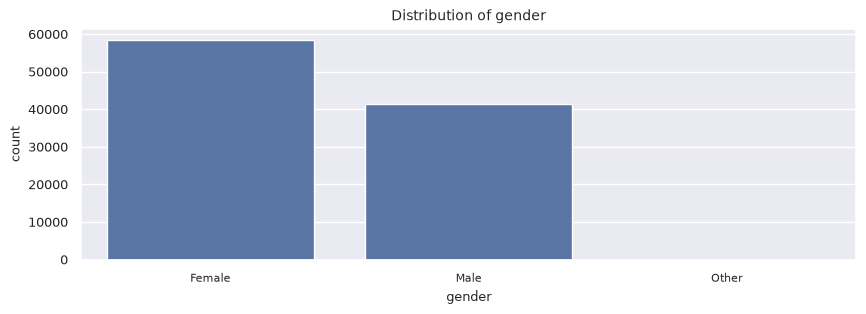

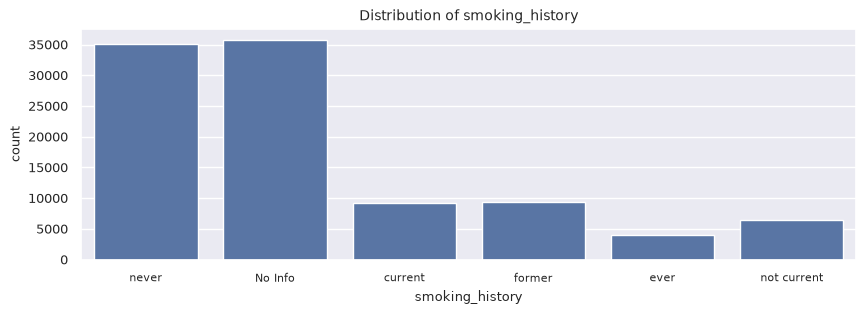

In [60]:
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [61]:
for col in cat_cols:
    print(df[col].value_counts())

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


Text(0.5, 1.0, 'Target distribution')

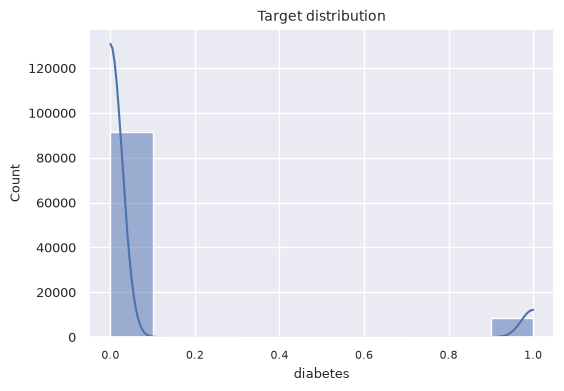

In [62]:
plt.figure(figsize=(6, 4))
sns.histplot(df[TARGET_COL], bins=10, kde=True)
plt.title("Target distribution")

In [63]:
df[TARGET_COL].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

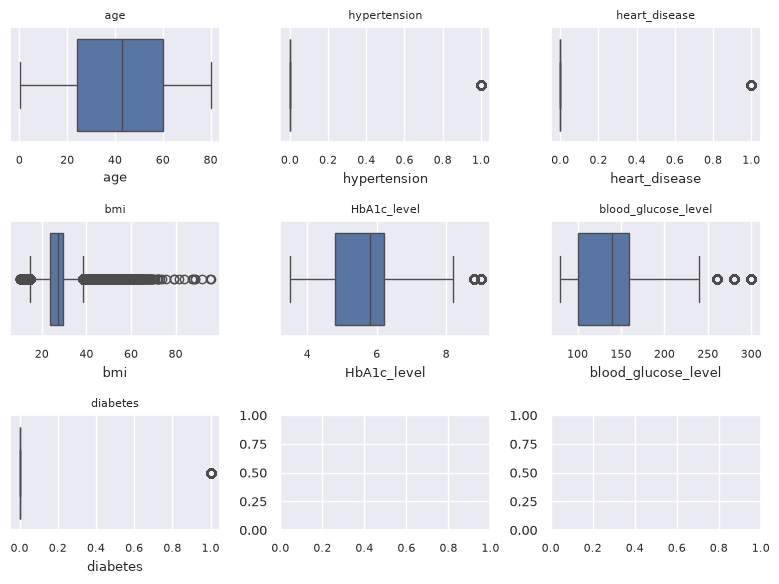

In [64]:
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

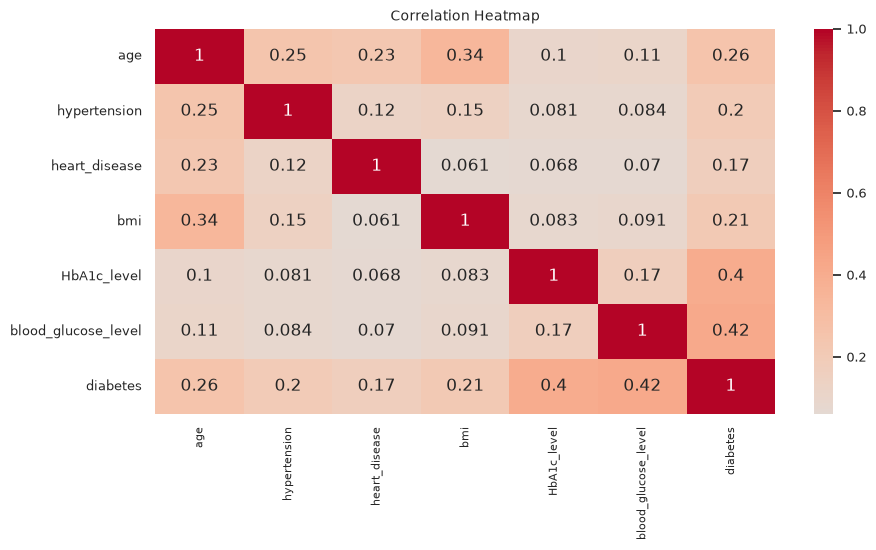

In [65]:
plt.figure(figsize=(10, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [66]:
# to show correlation heatmap in numerical form

corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print(corr_with_target)

diabetes              1.000
blood_glucose_level   0.420
HbA1c_level           0.401
age                   0.258
bmi                   0.214
hypertension          0.198
heart_disease         0.172
Name: diabetes, dtype: float64


datapreprocessing


In [67]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [68]:
X.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.000,0,1,never,25.190,6.600,140
1,Female,54.000,0,0,No Info,27.320,6.600,80
2,Male,28.000,0,0,never,27.320,5.700,158
3,Female,36.000,0,0,current,23.450,5.000,155
4,Male,76.000,1,1,current,20.140,4.800,155


In [69]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64

In [70]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train Shape", X_train.shape)
print("Test Shape", X_test.shape)

Train Shape (80000, 8)
Test Shape (20000, 8)


In [71]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numerical Columns:", numerical_features)
print("Categorical Columns:", categorical_features)

Numerical Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical Columns: ['gender', 'smoking_history']


In [72]:
# implementing pipeline to prevent data leakage

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        "onehot",
        OneHotEncoder(handle_unknown='ignore'),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [75]:
baseline_pipeline = Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',LogisticRegression(max_iter=1000))
    ]
)